Device: cpu

=== QAPINN detailed run (seed=42, epochs=8000) ===
Epoch      0 | total 2.206e+00 | pde 3.372e-08 | ic 2.297e-01 | bc 1.976e+00 | lr 1.0e-03
Epoch   1000 | total 3.524e-01 | pde 1.072e-05 | ic 2.618e-01 | bc 9.056e-02 | lr 1.0e-03
Epoch   2000 | total 3.645e-01 | pde 9.571e-05 | ic 2.719e-01 | bc 9.243e-02 | lr 5.0e-04
Epoch   3000 | total 2.863e-01 | pde 5.533e-03 | ic 1.991e-01 | bc 8.164e-02 | lr 5.0e-04
Epoch   4000 | total 1.294e-01 | pde 5.114e-02 | ic 5.473e-02 | bc 2.350e-02 | lr 2.5e-04
Epoch   5000 | total 1.169e-01 | pde 6.675e-02 | ic 3.303e-02 | bc 1.711e-02 | lr 2.5e-04
Epoch   6000 | total 1.084e-01 | pde 6.458e-02 | ic 2.941e-02 | bc 1.440e-02 | lr 1.3e-04
Epoch   7000 | total 1.065e-01 | pde 6.650e-02 | ic 2.637e-02 | bc 1.360e-02 | lr 1.3e-04

Trainable parameters:       18
Model memory (KB):          0.0703125
Peak training memory (MB):  64.16265296936035
Training time (s):          2045.588966369629
Relative L2 error:          0.16229505923800566
PDE re

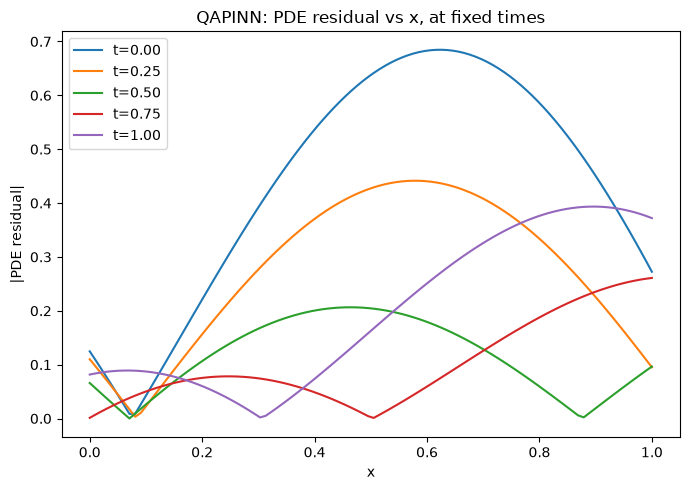

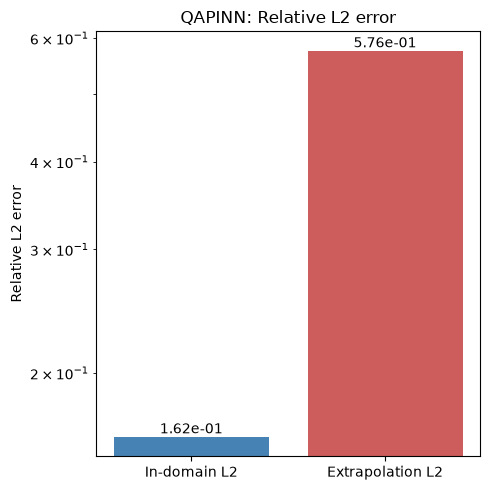

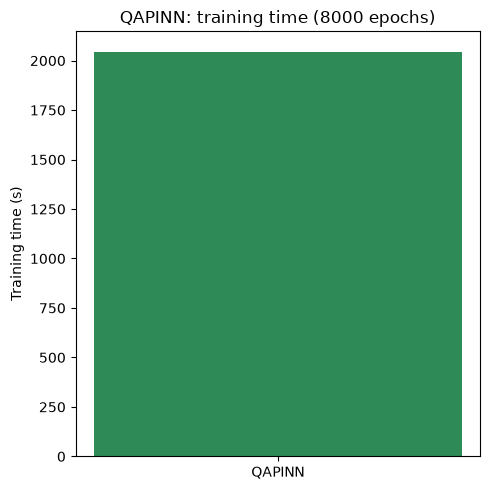

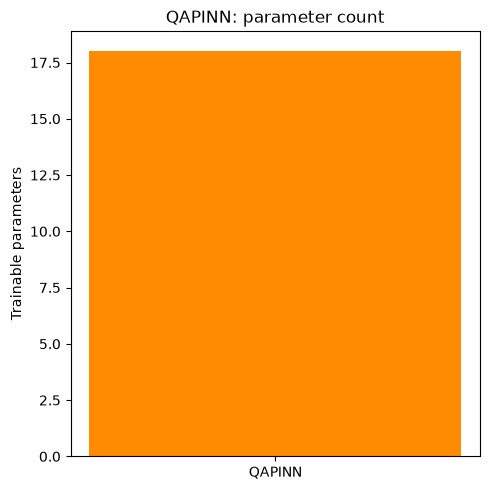

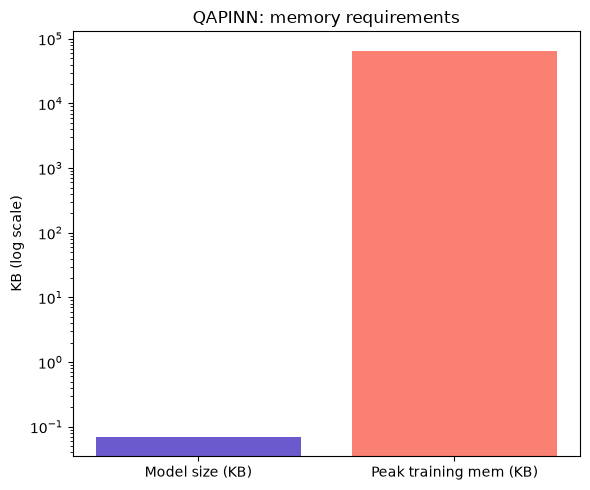

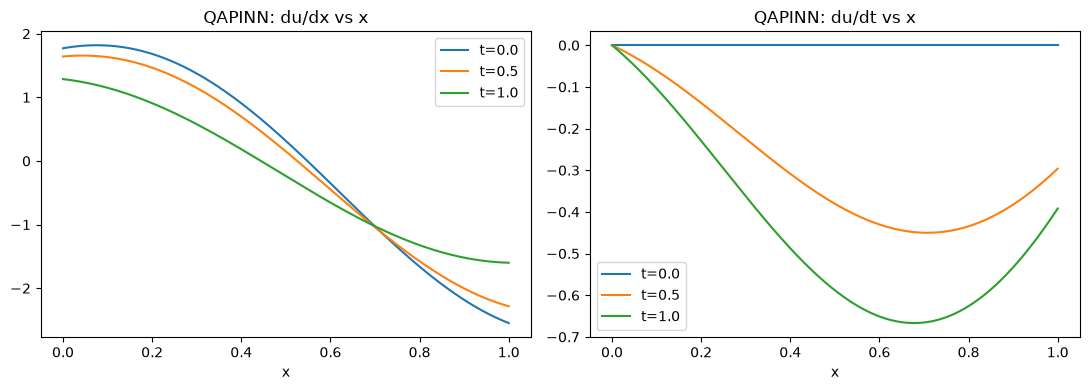

Quantum layer output (pre-readout) mean/std: (2.33139705657959, 0.6400302648544312)


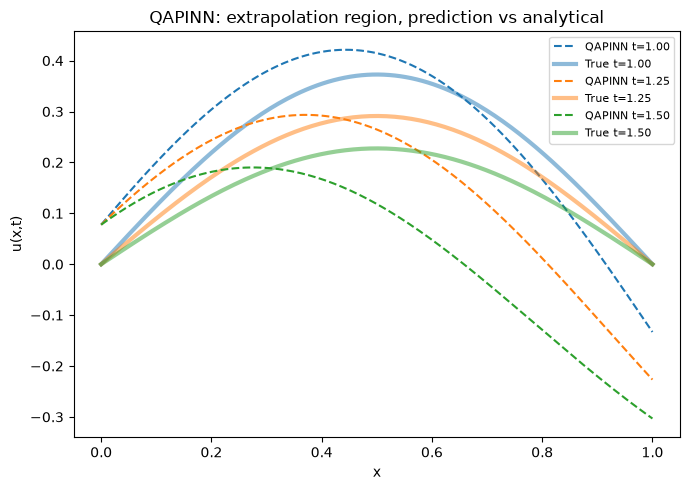

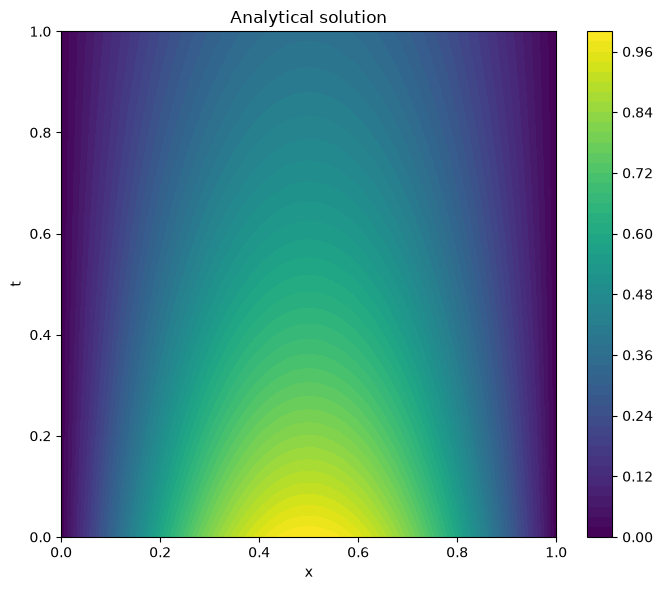

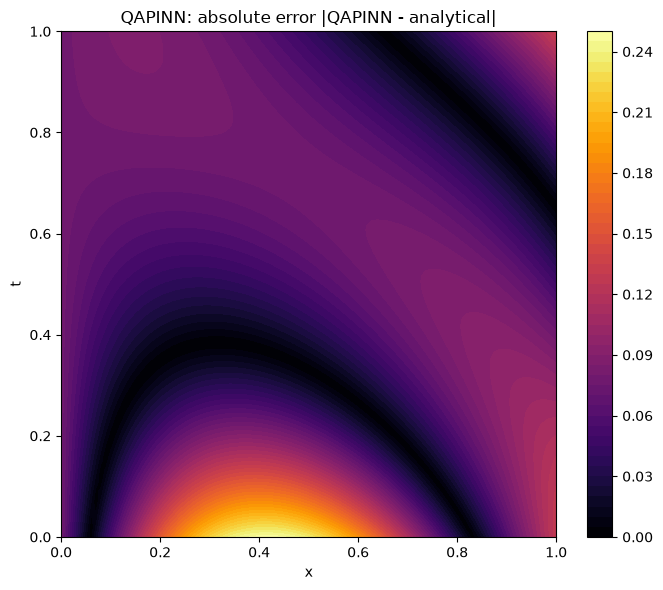

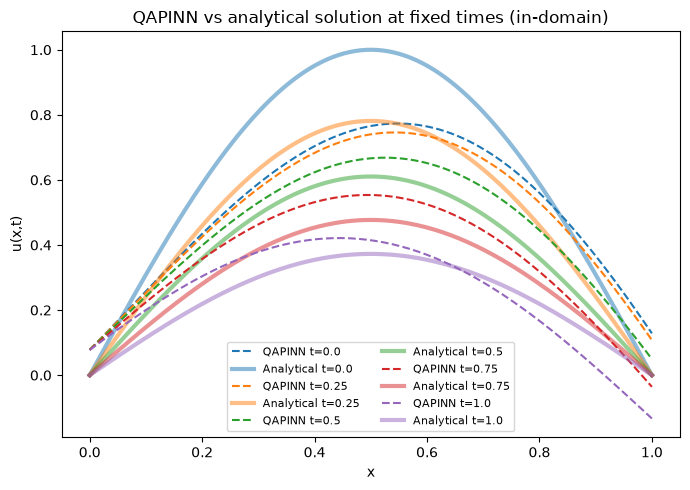


FINAL PDE RESIDUAL (dense grid, seed=42):
  MSE  = 6.445498e-02
  RMSE = 2.538798e-01



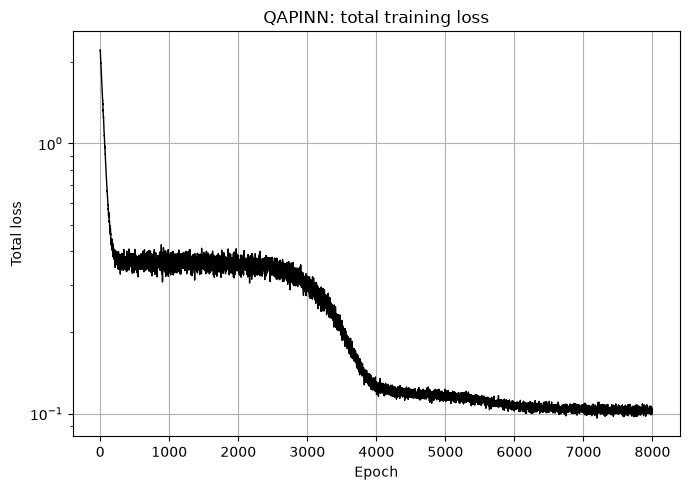

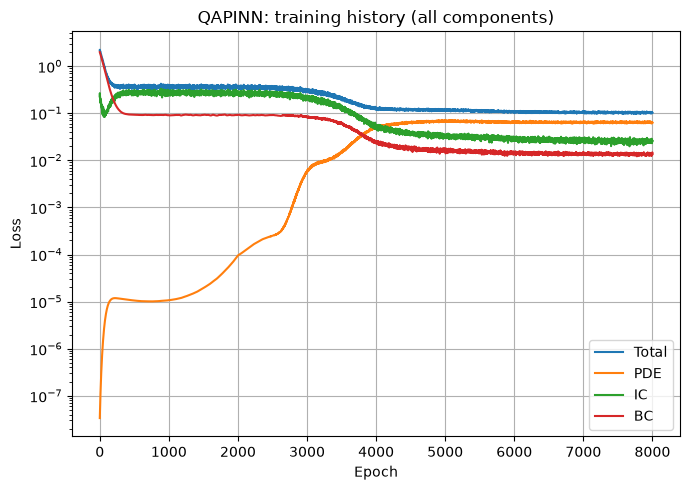

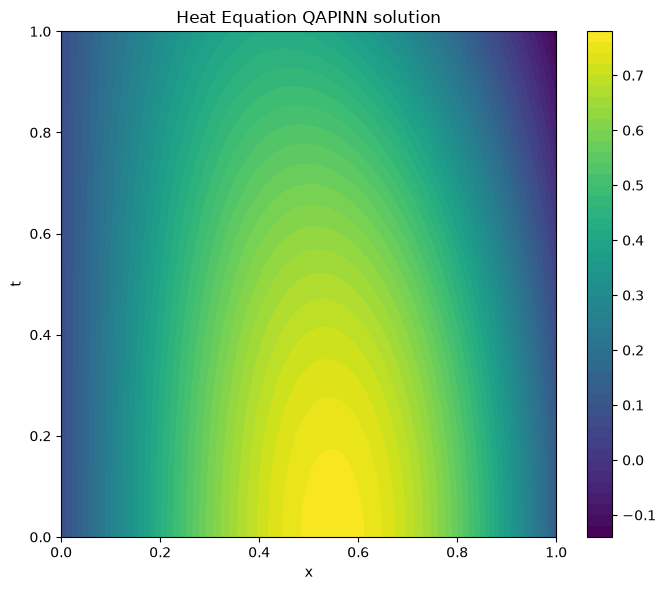

In [1]:
# ============================================================
# Quantum-Assisted Physics-Informed Neural Network (QAPINN)
# 1D Heat Equation -- PennyLane TorchLayer version
#
# PDE:      u_t - alpha * u_xx = 0,    x in [0,1], t in [0,T]
# IC:       u(x,0) = sin(pi*x)
# BC:       u(0,t) = u(1,t) = 0
#
# Circuit design:
#   - 4 qubits, 1 data re-uploading layers
#   - Encoding: RY(w_x * x), RZ(w_t * t) per qubit per layer (trainable
#     encoding weights)
#   - Variational: trainable RY, RZ per qubit per layer
#   - Entanglement: ring of CNOTs
#   - Measurement: sum of PauliZ over all qubits, expectation value
#   - Trainable affine readout (nn.Linear(1,1)) to calibrate output
#     scale/offset to the true solution's range
#

import time
import tracemalloc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pennylane as qml

from scipy.stats.qmc import LatinHypercube


# ============================================================
# Configuration
# ============================================================

ALPHA = 0.1
T_FINAL = 1.0
T_EXTRAPOLATE = 1.5

N_QUBITS = 4
N_LAYERS = 1

EPOCHS = 8000
LEARNING_RATE = 1e-3
LR_STEP_SIZE = 2000
LR_GAMMA = 0.5

N_F = 2000
N_0 = 200
N_B = 200

MAIN_SEED = 42

DEVICE = torch.device("cpu")  
print("Device:", DEVICE)

QDEV = qml.device("default.qubit", wires=N_QUBITS)


# ============================================================
# Quantum circuit (data re-uploading), wrapped for TorchLayer
# ============================================================

def make_qnode():
    @qml.qnode(QDEV, interface="torch", diff_method="backprop")
    def circuit(inputs, w_x, w_t, theta_y, theta_z):
        """
        inputs: tensor of shape (..., 2) -- columns [x, t]. TorchLayer
                passes the batch through this single 'inputs' argument;
                all other arguments are trainable weights (declared via
                weight_shapes below).
        w_x, w_t, theta_y, theta_z: shape (N_LAYERS, N_QUBITS), trainable.
        """
        x = inputs[..., 0]
        t = inputs[..., 1]

        for layer in range(N_LAYERS):
            # Encoding sub-layer
            for q in range(N_QUBITS):
                qml.RY(w_x[layer, q] * x, wires=q)
                qml.RZ(w_t[layer, q] * t, wires=q)
            # Variational sub-layer
            for q in range(N_QUBITS):
                qml.RY(theta_y[layer, q], wires=q)
                qml.RZ(theta_z[layer, q], wires=q)
            # Entanglement: ring of CNOTs
            for q in range(N_QUBITS):
                qml.CNOT(wires=[q, (q + 1) % N_QUBITS])

        observable = qml.sum(*[qml.PauliZ(q) for q in range(N_QUBITS)])
        return qml.expval(observable)

    return circuit


WEIGHT_SHAPES = {
    "w_x": (N_LAYERS, N_QUBITS),
    "w_t": (N_LAYERS, N_QUBITS),
    "theta_y": (N_LAYERS, N_QUBITS),
    "theta_z": (N_LAYERS, N_QUBITS),
}


# ============================================================
# QAPINN model
# ============================================================

class QAPINN(nn.Module):
    """
    Hybrid QAPINN: PennyLane TorchLayer (data re-uploading quantum
    circuit) + trainable affine readout.

    Forward pass:
        (x,t) --> quantum circuit --> <sum Z_i> in [-4,4] --> affine --> u
    """

    def __init__(self):
        super().__init__()
        circuit = make_qnode()

        # init_method receives an *empty tensor* of the target shape (not a
        # shape tuple) and must return a filled tensor of the same shape --
        # nn.init.normal_ does exactly this, in place.
        self.quantum_layer = qml.qnn.TorchLayer(
            circuit, WEIGHT_SHAPES,
            init_method=lambda tensor: nn.init.normal_(tensor, mean=0.0, std=0.1),
        )

        self.readout = nn.Linear(1, 1)
        with torch.no_grad():
            self.readout.weight.fill_(0.25)   # roughly maps [-4,4] -> [-1,1] (4 qubits)
            self.readout.bias.zero_()

    def forward(self, xt):
        # xt: shape (N, 2), columns [x, t] -- same input format as the
        # classical PINN.
        q_out = self.quantum_layer(xt)          # shape (N,)
        q_out = q_out.reshape(-1, 1).to(torch.float32)
        u = self.readout(q_out)
        return u


# ============================================================
# Collocation / IC / BC sampling
# ============================================================

def sample_points(lhs_sampler, N_f, N_0, N_b, T):
    pts = lhs_sampler.random(N_f)
    x_f = pts[:, 0:1]
    t_f = pts[:, 1:2] * T

    x0 = np.random.rand(N_0, 1)
    t0 = np.zeros_like(x0)
    u0 = np.sin(np.pi * x0)

    tb = np.random.rand(N_b, 1) * T
    xb0 = np.zeros_like(tb)
    xb1 = np.ones_like(tb)

    to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=DEVICE)

    return (
        to_t(x_f), to_t(t_f),
        to_t(x0), to_t(t0), to_t(u0),
        to_t(xb0), to_t(xb1), to_t(tb),
    )


# ============================================================
# PDE residual -- exact autograd (double backward confirmed working)
# ============================================================

def compute_residual(model, x, t, alpha):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)

    u = model(torch.cat([x, t], dim=1))

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    return u_t - alpha * u_xx


# ============================================================
# Loss function
# ============================================================

def loss_function(model, data, alpha, lambda_f=1.0, lambda_i=1.0, lambda_b=1.0):
    x_f, t_f, x0, t0, u0, xb0, xb1, tb = data

    residual = compute_residual(model, x_f, t_f, alpha)
    loss_pde = torch.mean(residual ** 2)

    u0_pred = model(torch.cat([x0, t0], dim=1))
    loss_ic = torch.mean((u0_pred - u0) ** 2)

    ub0 = model(torch.cat([xb0, tb], dim=1))
    ub1 = model(torch.cat([xb1, tb], dim=1))
    loss_bc = torch.mean(ub0 ** 2) + torch.mean(ub1 ** 2)

    total = lambda_f * loss_pde + lambda_i * loss_ic + lambda_b * loss_bc
    return total, loss_pde, loss_ic, loss_bc


# ============================================================
# Training loop 
# ============================================================

def train(model, lhs_sampler, epochs=EPOCHS, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

    history = {"total": [], "pde": [], "ic": [], "bc": []}

    start = time.time()
    for epoch in range(epochs):
        data = sample_points(lhs_sampler, N_F, N_0, N_B, T_FINAL)

        optimizer.zero_grad()
        loss, lpde, lic, lbc = loss_function(model, data, ALPHA)
        loss.backward()
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["pde"].append(lpde.item())
        history["ic"].append(lic.item())
        history["bc"].append(lbc.item())

        if verbose and epoch % 1000 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch:6d} | total {loss.item():.3e} | "
                  f"pde {lpde.item():.3e} | ic {lic.item():.3e} | bc {lbc.item():.3e} | "
                  f"lr {current_lr:.1e}")

    training_time = time.time() - start
    return history, training_time


# ============================================================
#  PDE residual error + relative L2 error
# ============================================================

def exact_solution(x, t, alpha=ALPHA):
    return np.exp(-alpha * np.pi ** 2 * t) * np.sin(np.pi * x)


def evaluate(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2 = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return pred, true, X, Tt, L2


def pde_residual_error(model, T=T_FINAL, n_x=100, n_t=100):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    residual = compute_residual(model, xt, tt, ALPHA).detach().cpu().numpy()
    mse = np.mean(residual ** 2)
    rmse = np.sqrt(mse)
    return mse, rmse, residual.reshape(X.shape), X, Tt


# ============================================================
#  parameter count and memory
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_memory_bytes(model):
    return sum(p.numel() * p.element_size() for p in model.parameters())


# ============================================================
#  Explainability
#
# Note on interpretation: the classical PINN's "per-layer activation
# stats" metric doesn't map 1:1 onto a single quantum circuit block --
# there isn't a stack of hidden layers to probe individually. The
# closest analogues used here:
#   (a) sensitivity slices: du/dx, du/dt vs x, at fixed t (same as
#       classical -- directly comparable)
#   (b) quantum-layer OUTPUT distribution (pre-readout): mean/std of
#       <sum Z_i> across a sample grid, i.e. how the circuit itself
#       (before classical calibration) uses its output range
# ============================================================

def sensitivity_slices(model, T=T_FINAL, times=(0.0, 0.5, 1.0), n_x=200):
    x = np.linspace(0, 1, n_x)
    results = {}
    for t_val in times:
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32,
                            device=DEVICE, requires_grad=True)
        t_t = torch.full_like(x_t, t_val, requires_grad=True)
        u = model(torch.cat([x_t, t_t], dim=1))
        u_x = torch.autograd.grad(u, x_t, torch.ones_like(u), retain_graph=True)[0]
        u_t = torch.autograd.grad(u, t_t, torch.ones_like(u))[0]
        results[t_val] = (
            u_x.detach().cpu().numpy().flatten(),
            u_t.detach().cpu().numpy().flatten(),
        )
    return x, results


def quantum_output_stats(model, n_x=20, n_t=20):
    """Mean/std of the quantum layer's raw output (pre-readout), across
    a grid of (x,t) -- the closest quantum analogue to 'activation stats'."""
    x = np.linspace(0, 1, n_x)
    t = np.linspace(0, T_FINAL, n_t)
    X, Tt = np.meshgrid(x, t)
    xt = torch.tensor(
        np.stack([X.flatten(), Tt.flatten()], axis=1), dtype=torch.float32
    )
    with torch.no_grad():
        q_out = model.quantum_layer(xt)
    q_out = q_out.numpy()
    return {"quantum_output": (float(q_out.mean()), float(q_out.std()))}


# ============================================================
#  performance on unseen domain (temporal extrapolation)
# ============================================================

def extrapolation_test(model, T_train=T_FINAL, T_extra=T_EXTRAPOLATE, n_x=100, n_t=50):
    x = np.linspace(0, 1, n_x)
    t = np.linspace(T_train, T_extra, n_t)
    X, Tt = np.meshgrid(x, t)

    xt = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    tt = torch.tensor(Tt.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(torch.cat([xt, tt], dim=1)).cpu().numpy().reshape(X.shape)

    true = exact_solution(X, Tt)
    L2_extra = np.linalg.norm(pred - true) / np.linalg.norm(true)

    return L2_extra, pred, true, X, Tt


# ============================================================
# Single full experiment (train + all metrics), given a seed
# ============================================================

def run_experiment(seed, epochs=EPOCHS, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    lhs_sampler = LatinHypercube(d=2, seed=seed)

    model = QAPINN().to(DEVICE)
    n_params = count_parameters(model)
    mem_bytes = model_memory_bytes(model)

    tracemalloc.start()
    history, training_time = train(model, lhs_sampler, epochs=epochs, verbose=verbose)
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    pred, true, X, Tt, l2_error = evaluate(model)
    mse_res, rmse_res, res_field, Xr, Ttr = pde_residual_error(model)
    l2_extra, pred_extra, true_extra, X_extra, Tt_extra = extrapolation_test(model)

    return {
        "seed": seed,
        "model": model,
        "history": history,
        "training_time": training_time,
        "n_params": n_params,
        "model_mem_kb": mem_bytes / 1024,
        "peak_mem_mb": peak_mem / 1024 ** 2,
        "l2_error": l2_error,
        "pde_mse": mse_res,
        "pde_rmse": rmse_res,
        "l2_extrapolation": l2_extra,
        "eval_grids": (pred, true, X, Tt),
        "residual_grid": (res_field, Xr, Ttr),
        "extrapolation_grids": (pred_extra, true_extra, X_extra, Tt_extra),
    }


# ============================================================
# Run: single detailed run, all metrics and plots
# ============================================================

if __name__ == "__main__":

    print(f"\n=== QAPINN detailed run (seed={MAIN_SEED}, epochs={EPOCHS}) ===")
    result = run_experiment(MAIN_SEED, epochs=EPOCHS, verbose=True)

    model = result["model"]
    history = result["history"]
    pred, true, X, Tt = result["eval_grids"]
    res_field, Xr, Ttr = result["residual_grid"]
    pred_extra, true_extra, X_extra, Tt_extra = result["extrapolation_grids"]

    print("\n==============================")
    print("Trainable parameters:      ", result["n_params"])
    print("Model memory (KB):         ", result["model_mem_kb"])
    print("Peak training memory (MB): ", result["peak_mem_mb"])
    print("Training time (s):         ", result["training_time"])
    print("Relative L2 error:         ", result["l2_error"])
    print("PDE residual MSE / RMSE:   ", result["pde_mse"], "/", result["pde_rmse"])
    print("Extrapolation L2 (t up to %.1f): %.4e" % (T_EXTRAPOLATE, result["l2_extrapolation"]))
    print("==============================\n")

    #  PDE residual, as error-vs-x slices ---
    plt.figure(figsize=(7, 5))
    for t_val in np.linspace(0, T_FINAL, 5):
        idx = int(t_val / T_FINAL * (Ttr.shape[0] - 1))
        plt.plot(Xr[idx], np.abs(res_field[idx]), label=f"t={t_val:.2f}")
    plt.xlabel("x"); plt.ylabel("|PDE residual|")
    plt.title("QAPINN: PDE residual vs x, at fixed times")
    plt.legend()
    plt.tight_layout()
    plt.savefig("qapinn_metric1_pde_residual_slices.png", dpi=150)
    plt.show()

    #  Relative L2 error summary bar chart ---
    plt.figure(figsize=(5, 5))
    labels = ["In-domain L2", "Extrapolation L2"]
    values = [result["l2_error"], result["l2_extrapolation"]]
    bars = plt.bar(labels, values, color=["steelblue", "indianred"])
    plt.yscale("log")
    plt.ylabel("Relative L2 error")
    plt.title("QAPINN: Relative L2 error")
    for b, v in zip(bars, values):
        plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.2e}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig("qapinn_metric2_l2_error.png", dpi=150)
    plt.show()

    # training time ---
    plt.figure(figsize=(5, 5))
    plt.bar(["QAPINN"], [result["training_time"]], color="seagreen")
    plt.ylabel("Training time (s)")
    plt.title(f"QAPINN: training time ({EPOCHS} epochs)")
    plt.tight_layout()
    plt.savefig("qapinn_metric3_training_time.png", dpi=150)
    plt.show()

    # parameter count ---
    plt.figure(figsize=(5, 5))
    plt.bar(["QAPINN"], [result["n_params"]], color="darkorange")
    plt.ylabel("Trainable parameters")
    plt.title("QAPINN: parameter count")
    plt.tight_layout()
    plt.savefig("qapinn_metric4_param_count.png", dpi=150)
    plt.show()

    #  memory ---
    plt.figure(figsize=(6, 5))
    plt.bar(["Model size (KB)"], [result["model_mem_kb"]], color="slateblue")
    plt.bar(["Peak training mem (KB)"], [result["peak_mem_mb"] * 1024], color="salmon")
    plt.yscale("log")
    plt.ylabel("KB (log scale)")
    plt.title("QAPINN: memory requirements")
    plt.tight_layout()
    plt.savefig("qapinn_metric5_memory.png", dpi=150)
    plt.show()

    #  sensitivity slices ---
    x_s, sens = sensitivity_slices(model)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for t_val, (u_x, u_t) in sens.items():
        axes[0].plot(x_s, u_x, label=f"t={t_val}")
        axes[1].plot(x_s, u_t, label=f"t={t_val}")
    axes[0].set_title("QAPINN: du/dx vs x"); axes[0].set_xlabel("x"); axes[0].legend()
    axes[1].set_title("QAPINN: du/dt vs x"); axes[1].set_xlabel("x"); axes[1].legend()
    plt.tight_layout()
    plt.savefig("qapinn_metric6a_sensitivity_slices.png", dpi=150)
    plt.show()

    #  quantum output distribution (pre-readout) ---
    q_stats = quantum_output_stats(model)
    print("Quantum layer output (pre-readout) mean/std:", q_stats["quantum_output"])

    # extrapolation, as prediction-vs-true slices ---
    plt.figure(figsize=(7, 5))
    x = np.linspace(0, 1, 200)
    for t_val in (T_FINAL, (T_FINAL + T_EXTRAPOLATE) / 2, T_EXTRAPOLATE):
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        t_t = torch.full_like(x_t, t_val)
        with torch.no_grad():
            u_pred = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
        u_true = exact_solution(x, t_val)
        line, = plt.plot(x, u_pred, "--", label=f"QAPINN t={t_val:.2f}")
        plt.plot(x, u_true, color=line.get_color(), alpha=0.5, linewidth=3,
                 label=f"True t={t_val:.2f}")
    plt.xlabel("x"); plt.ylabel("u(x,t)")
    plt.title("QAPINN: extrapolation region, prediction vs analytical")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("qapinn_metric7_extrapolation_slices.png", dpi=150)
    plt.show()

    # --- Exact solution heatmap ---
    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X, Tt, true, levels=50, cmap="viridis")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Analytical solution")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("qapinn_exact_solution_contour.png", dpi=150)
    plt.show()

    # --- Absolute error heatmap ---
    plt.figure(figsize=(7, 6))
    err_field = np.abs(pred - true)
    cf = plt.contourf(X, Tt, err_field, levels=50, cmap="inferno")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("QAPINN: absolute error |QAPINN - analytical|")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("qapinn_absolute_error_contour.png", dpi=150)
    plt.show()

    # --- Slice comparison: QAPINN vs analytical, in-domain ---
    plt.figure(figsize=(7, 5))
    x = np.linspace(0, 1, 200)
    for t_val in (0.0, 0.25, 0.5, 0.75, 1.0):
        x_t = torch.tensor(x.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
        t_t = torch.full_like(x_t, t_val)
        with torch.no_grad():
            u_pred = model(torch.cat([x_t, t_t], dim=1)).cpu().numpy().flatten()
        u_true = exact_solution(x, t_val)
        line, = plt.plot(x, u_pred, "--", label=f"QAPINN t={t_val}")
        plt.plot(x, u_true, color=line.get_color(), alpha=0.5, linewidth=3,
                 label=f"Analytical t={t_val}")
    plt.xlabel("x"); plt.ylabel("u(x,t)")
    plt.title("QAPINN vs analytical solution at fixed times (in-domain)")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig("qapinn_slice_comparison_indomain.png", dpi=150)
    plt.show()

    # --- Final PDE residual number, clearly reported ---
    print("\n==============================")
    print(f"FINAL PDE RESIDUAL (dense grid, seed={MAIN_SEED}):")
    print(f"  MSE  = {result['pde_mse']:.6e}")
    print(f"  RMSE = {result['pde_rmse']:.6e}")
    print("==============================\n")

    # --- Total loss history ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], color="black", linewidth=1)
    plt.xlabel("Epoch"); plt.ylabel("Total loss")
    plt.title("QAPINN: total training loss")
    plt.grid()
    plt.tight_layout()
    plt.savefig("qapinn_total_loss_history.png", dpi=150)
    plt.show()

    # --- All-component loss history ---
    plt.figure(figsize=(7, 5))
    plt.semilogy(history["total"], label="Total")
    plt.semilogy(history["pde"], label="PDE")
    plt.semilogy(history["ic"], label="IC")
    plt.semilogy(history["bc"], label="BC")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()
    plt.title("QAPINN: training history (all components)")
    plt.grid()
    plt.tight_layout()
    plt.savefig("qapinn_loss_history.png", dpi=150)
    plt.show()

    # --- QAPINN solution contour (prediction) ---
    plt.figure(figsize=(7, 6))
    cf = plt.contourf(X, Tt, pred, levels=50, cmap="viridis")
    plt.xlabel("x"); plt.ylabel("t")
    plt.title("Heat Equation QAPINN solution")
    plt.colorbar(cf)
    plt.tight_layout()
    plt.savefig("qapinn_solution_contour.png", dpi=150)
    plt.show()


result_qapinn = result
